# Semantic, Topic, and Represented Vector for One News Sample

Notebook này lấy một sample từ dataset news, tạo semantic embedding, topic embedding bằng topic model đã lưu, rồi tổng hợp hai embedding thành represented vector.

In [1]:
import os
import sys
import numpy as np

np.set_printoptions(
    precision=6,
    suppress=True,
    linewidth=200,
)

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root: {project_root}")

Project root: d:\CDNC\MIND-research


In [2]:
from pathlib import Path
import pandas as pd

set_names = ["train_set", "dev_set", "test_set"]
data_root = Path(project_root) / "data" / "primary"

statistics = []
for set_name in set_names:
    set_root = data_root / set_name
    statistics.append(
        {
            "Set": set_name.replace("_set", ""),
            "News": sum(1 for _ in open(set_root / "news.tsv", encoding="utf-8")),
            "Behaviors": sum(
                1 for _ in open(set_root / "behaviors.tsv", encoding="utf-8")
            ),
        }
    )

statistics_df = pd.DataFrame(statistics)
display(statistics_df)


,Set,News,Behaviors
0,train,101527,2232748
1,dev,72023,376471
2,test,120961,2370727


In [2]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

from src.core.Context import VectorContext
from src.represent.RepresentedVector import RepresentedVector

In [3]:
news_dir = os.path.join(project_root, "data", "primary", "dev_set")
context = VectorContext(news_dir)
title_list = context.createTitleList()

sample = title_list[0]

print("Sample news:")
print(sample)

Sample news:
{'news_id': 'N88753', 'title': 'The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By'}


In [4]:
semantic_model = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")
topic_model_path = os.path.join(project_root, "models", "primary", "bertopic")
topic_model = BERTopic.load(topic_model_path)

print(f"Loaded topic model from: {topic_model_path}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded topic model from: d:\CDNC\MIND-research\models\primary\bertopic


In [5]:
semantic_embedding = semantic_model.encode(
    [sample["title"]],
    show_progress_bar=False,
    convert_to_numpy=True,
)[0]

print("Semantic embedding:")
print(semantic_embedding)
print(f"Shape: {semantic_embedding.shape}")

Semantic embedding:
[-0.009286  0.042442  0.058988  0.012106  0.033419  0.019646  0.027369 -0.061527 -0.036167 -0.039047 -0.022194 -0.010343  0.028815 -0.092197 -0.013044  0.002547  0.020389  0.062189 -0.018131
  0.009451  0.041563 -0.040626  0.054083  0.082064 -0.131597  0.006012 -0.023924  0.062581 -0.008295 -0.129473 -0.100346 -0.00731   0.062085  0.010478  0.006402 -0.030482  0.007456  0.065136
  0.027368 -0.008952  0.082453 -0.089669 -0.000359  0.030352  0.008877  0.028702  0.015467  0.07677   0.003742 -0.011441  0.019365  0.037517  0.019194 -0.074235 -0.034077 -0.034682 -0.051848
 -0.086053  0.075468  0.036657 -0.0131    0.068174  0.018155  0.068547 -0.059816  0.04214  -0.038056  0.027713 -0.051356  0.006359 -0.024797 -0.085889  0.075542  0.003419 -0.119873  0.060337
  0.075755 -0.029483 -0.064855  0.010058 -0.130292 -0.039882 -0.034173  0.017582 -0.032337 -0.02341   0.011045 -0.061783 -0.026783  0.016306  0.015398 -0.018851  0.082801  0.031754 -0.024143
  0.034919  0.080031 -0.0

In [8]:
_, topic_embedding = topic_model.transform(
    [sample["title"]],
    embeddings=semantic_embedding.reshape(1, -1),
)
topic_embedding = topic_embedding[0]

print("Topic embedding (topic distribution):")
print(topic_embedding)
print(f"Shape: {topic_embedding.shape}")

Topic embedding (topic distribution):
[0.000777 0.001208 0.000894 0.000943 0.000871 0.001013 0.001316 0.000971 0.000886 0.000894 0.001329 0.00072  0.000988 0.001718 0.000826 0.000946 0.001922 0.000985 0.001197 0.095492 0.000722 0.000714
 0.001497 0.000934 0.000744 0.000726 0.001154 0.000779 0.000702 0.001216 0.001634 0.001065 0.000879 0.000742 0.000841 0.000841 0.000979 0.001082 0.000961 0.000765 0.002299 0.001086 0.00088  0.001553
 0.000644 0.001072 0.000809 0.001573 0.000954 0.000713 0.002321 0.000648 0.001392 0.001011 0.000632 0.001001 0.0023   0.001245 0.001074 0.000935 0.000671 0.000714 0.001009 0.001339 0.000793 0.000981
 0.000988 0.000962 0.00093  0.000631 0.000789 0.001315 0.001185 0.00108  0.000897 0.001021 0.001069 0.000945 0.000995 0.00106  0.000709 0.00127  0.000639 0.000701 0.001354 0.001255 0.001636 0.001114
 0.000659 0.001241 0.000752 0.000915 0.001189 0.001098 0.000706 0.001498 0.001056 0.000664 0.000709 0.00105  0.000702 0.000651 0.001341 0.000645 0.000659 0.001353 0.0

In [7]:
represented_model = RepresentedVector(semantic_model, topic_model)
represented = represented_model.get_vector(sample["title"])

print("Represented vector:")
print(represented)
print("\nSemantic component:")
print(represented["semantic"])
print("\nTopic distribution component:")
print(represented["topic_distribution"])
print(f"Semantic shape: {represented['semantic'].shape}")
print(f"Topic distribution shape: {represented['topic_distribution'].shape}")

Represented vector:
{'semantic': array([-0.009286,  0.042442,  0.058988,  0.012106,  0.033419,  0.019646,  0.027369, -0.061527, -0.036167, -0.039047, -0.022194, -0.010343,  0.028815, -0.092197, -0.013044,  0.002547,  0.020389,
        0.062189, -0.018131,  0.009451,  0.041563, -0.040626,  0.054083,  0.082064, -0.131597,  0.006012, -0.023924,  0.062581, -0.008295, -0.129473, -0.100346, -0.00731 ,  0.062085,  0.010478,
        0.006402, -0.030482,  0.007456,  0.065136,  0.027368, -0.008952,  0.082453, -0.089669, -0.000359,  0.030352,  0.008877,  0.028702,  0.015467,  0.07677 ,  0.003742, -0.011441,  0.019365,
        0.037517,  0.019194, -0.074235, -0.034077, -0.034682, -0.051848, -0.086053,  0.075468,  0.036657, -0.0131  ,  0.068174,  0.018155,  0.068547, -0.059816,  0.04214 , -0.038056,  0.027713,
       -0.051356,  0.006359, -0.024797, -0.085889,  0.075542,  0.003419, -0.119873,  0.060337,  0.075755, -0.029483, -0.064855,  0.010058, -0.130292, -0.039882, -0.034173,  0.017582, -0.03233

In [10]:
import pickle

from src.core.Context import VectorContext
from src.urv.URV import URV

user_context = VectorContext(
    os.path.join(project_root, "data", "primary", "dev_set")
)
behaviours = user_context.createImpressed()

represented_vectors_path = os.path.join(
    project_root,
    "vectors",
    "primary",
    "represent_vectors.pkl",
)

with open(represented_vectors_path, "rb") as file:
    represented_vector = pickle.load(file)

selected_user = None

for behavior_id, behavior in behaviours.items():
    history_ids = behavior["history"].split()
    impression_ids = [item["news_id"] for item in behavior["impressions"]]

    has_short_history = 5 <= len(history_ids) <= 6
    has_short_impressions = 5 <= len(impression_ids) <= 6
    history_vectors_exist = all(news_id in represented_vector for news_id in history_ids)

    if has_short_history and has_short_impressions and history_vectors_exist:
        selected_user = {
            "behavior_id": behavior_id,
            "user_id": behavior["user_id"],
            "history": history_ids,
            "impressions": impression_ids,
        }
        break

if selected_user is None:
    raise ValueError(
        "Không tìm thấy user có 5-6 history, 5-6 impressions "
        "và đủ represented vector cho toàn bộ history."
    )

print("Selected user:")
print(f"Behavior ID: {selected_user['behavior_id']}")
print(f"User ID: {selected_user['user_id']}")
print(f"History ({len(selected_user['history'])}): {selected_user['history']}")
print(f"Impressions ({len(selected_user['impressions'])}): {selected_user['impressions']}")

urv = URV()
user_urv = urv.getURV(
    " ".join(selected_user["history"]),
    represented_vector,
)

print("\nUser Represented Vector (URV):")
print("Semantic, first 10 values:")
print(user_urv["semantic"][:10])
print("Topic distribution, first 10 values:")
print(user_urv["topic_distribution"][:10])
print(f"Semantic shape: {user_urv['semantic'].shape}")
print(f"Topic distribution shape: {user_urv['topic_distribution'].shape}")

Selected user:
Behavior ID: 83
User ID: U713932
History (6): ['N115895', 'N44660', 'N88892', 'N126063', 'N91597', 'N123455']
Impressions (5): ['N18190', 'N55801', 'N25621', 'N54368', 'N122640']

User Represented Vector (URV):
Semantic, first 10 values:
[-0.007737  0.012451 -0.002476  0.014146  0.03663  -0.006671  0.04219  -0.015537  0.004409 -0.012908]
Topic distribution, first 10 values:
[0.000052 0.000091 0.000058 0.000086 0.000078 0.0001   0.000121 0.000085 0.000059 0.000059]
Semantic shape: (384,)
Topic distribution shape: (690,)


In [13]:
from src.recommendation.RecommendationEngine import RecommendationEngine

candidate_news = [
    {
        "news_id": impression_id,
        "vector": represented_vector[impression_id],
        "label": next(
            item["label"]
            for behavior in behaviours.values()
            if behavior["user_id"] == selected_user["user_id"]
            for item in behavior["impressions"]
            if item["news_id"] == impression_id
        ),
    }
    for impression_id in selected_user["impressions"]
    if impression_id in represented_vector
]

recommender = RecommendationEngine(alpha=0.75)
ranked_results = recommender.recommended_with_label(
    user_vector=user_urv,
    candidate_news=candidate_news,
)

print("Sorted recommendation results:")
for rank, result in enumerate(ranked_results, start=1):
    print(
        f"{rank}. News ID: {result['news_id']} | "
        f"Label: {result['label']} | "
        f"Score: {result['score']:.6f} | "
        f"Semantic: {result['semantic_score']:.6f} | "
        f"Topic: {result['topic_score']:.6f}"
    )

Sorted recommendation results:
1. News ID: N54368 | Label: 1 | Score: 0.169527 | Semantic: 0.225934 | Topic: 0.000304
2. News ID: N122640 | Label: 0 | Score: 0.143346 | Semantic: 0.191078 | Topic: 0.000151
3. News ID: N18190 | Label: 0 | Score: 0.082895 | Semantic: 0.109561 | Topic: 0.002898
4. News ID: N25621 | Label: 0 | Score: 0.066907 | Semantic: 0.088898 | Topic: 0.000937
5. News ID: N55801 | Label: 0 | Score: 0.044358 | Semantic: 0.045168 | Topic: 0.041927


In [14]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

results_path = os.path.join(project_root, "results", "tuning_results.pkl")
legacy_results_path = os.path.join(project_root, "vectors", "tuning_alpha_results.pkl")

if os.path.exists(results_path):
    tuning_path = results_path
elif os.path.exists(legacy_results_path):
    tuning_path = legacy_results_path
else:
    raise FileNotFoundError("Không tìm thấy file tuning results.")

with open(tuning_path, "rb") as file:
    tuning_data = pickle.load(file)

if isinstance(tuning_data, pd.DataFrame):
    tuning_df = tuning_data.copy()
elif isinstance(tuning_data, dict):
    tuning_df = pd.DataFrame.from_dict(tuning_data, orient="index")
    tuning_df.index.name = "alpha"
    tuning_df = tuning_df.reset_index()
elif isinstance(tuning_data, list):
    tuning_df = pd.DataFrame(tuning_data)
else:
    raise TypeError(f"Định dạng tuning không được hỗ trợ: {type(tuning_data)}")

if "alpha" not in tuning_df.columns:
    if "Alpha" in tuning_df.columns:
        tuning_df = tuning_df.rename(columns={"Alpha": "alpha"})
    else:
        raise KeyError("Bảng tuning không có cột alpha.")

tuning_df["alpha"] = tuning_df["alpha"].astype(float)
tuning_df = tuning_df.sort_values("alpha").reset_index(drop=True)

print(f"Loaded tuning results from: {tuning_path}")
print("Tuning results table:")
display(tuning_df)

Loaded tuning results from: d:\CDNC\MIND-research\results\tuning_results.pkl
Tuning results table:


,alpha,AUC,MRR,nDCG@5,nDCG@10,HitRate@5,HitRate@10,TotalScore
0,0.00,0.573018,0.305782,0.284198,0.345361,0.473728,0.658374,2.640462
1,0.05,0.603976,0.315807,0.296554,0.356607,0.492874,0.672890,2.738707
2,0.10,0.611148,0.319788,0.301488,0.361228,0.500587,0.679045,2.773285
3,0.15,0.616157,0.323398,0.305542,0.365421,0.506614,0.684963,2.802095
4,0.20,0.620450,0.326842,0.309434,0.369300,0.512238,0.690193,2.828456
5,0.25,0.624524,0.330596,0.313336,0.373272,0.517359,0.695034,2.854121
6,0.30,0.628127,0.334146,0.317101,0.377077,0.522249,0.699837,2.878537
7,0.35,0.631380,0.337767,0.320686,0.380787,0.526357,0.704094,2.901071
8,0.40,0.634149,0.341247,0.324198,0.384212,0.530782,0.707747,2.922336
9,0.45,0.636415,0.344239,0.327058,0.387254,0.534183,0.711356,2.940504


In [15]:
metric_columns = [
    "AUC",
    "MRR",
    "nDCG@5",
    "nDCG@10",
]

missing_metrics = [metric for metric in metric_columns if metric not in tuning_df.columns]
if missing_metrics:
    raise KeyError(f"Thiếu metric trong tuning results: {missing_metrics}")

scores = {
    metric: tuning_df[metric].astype(float).tolist()
    for metric in metric_columns
}
scores["Total"] = pd.DataFrame(scores).mean(axis=1).tolist()

tuning_summary_df = tuning_df[["alpha", *metric_columns]].copy()
tuning_summary_df["Total"] = scores["Total"]

display(tuning_summary_df)

best_scores = []
for metric, values in scores.items():
    best_index = int(np.argmax(values))
    best_scores.append(
        {
            "Metric": metric,
            "Best Alpha": tuning_df.loc[best_index, "alpha"],
            "Best Score": values[best_index],
        }
    )

best_scores_df = pd.DataFrame(best_scores).sort_values(
    "Best Score",
    ascending=False,
).reset_index(drop=True)

print("Best score by metric:")
display(best_scores_df)

,alpha,AUC,MRR,nDCG@5,nDCG@10,Total
0,0.00,0.573018,0.305782,0.284198,0.345361,0.377090
1,0.05,0.603976,0.315807,0.296554,0.356607,0.393236
2,0.10,0.611148,0.319788,0.301488,0.361228,0.398413
3,0.15,0.616157,0.323398,0.305542,0.365421,0.402629
4,0.20,0.620450,0.326842,0.309434,0.369300,0.406506
5,0.25,0.624524,0.330596,0.313336,0.373272,0.410432
6,0.30,0.628127,0.334146,0.317101,0.377077,0.414113
7,0.35,0.631380,0.337767,0.320686,0.380787,0.417655
8,0.40,0.634149,0.341247,0.324198,0.384212,0.420952
9,0.45,0.636415,0.344239,0.327058,0.387254,0.423741


Best score by metric:


,Metric,Best Alpha,Best Score
0,AUC,0.70,0.640750
1,Total,0.75,0.431691
2,nDCG@10,0.75,0.396010
3,MRR,0.75,0.354431
4,nDCG@5,0.75,0.335947


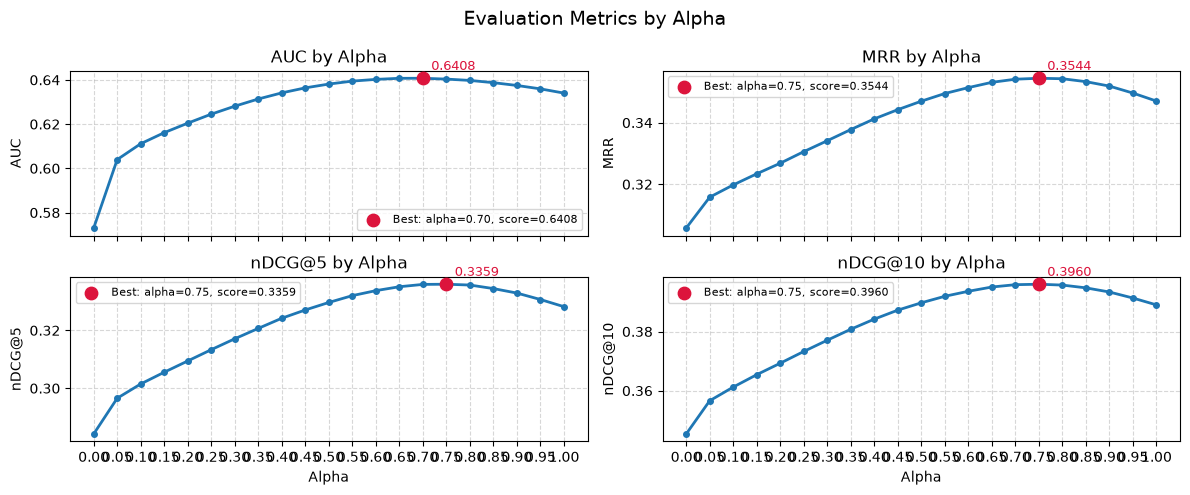

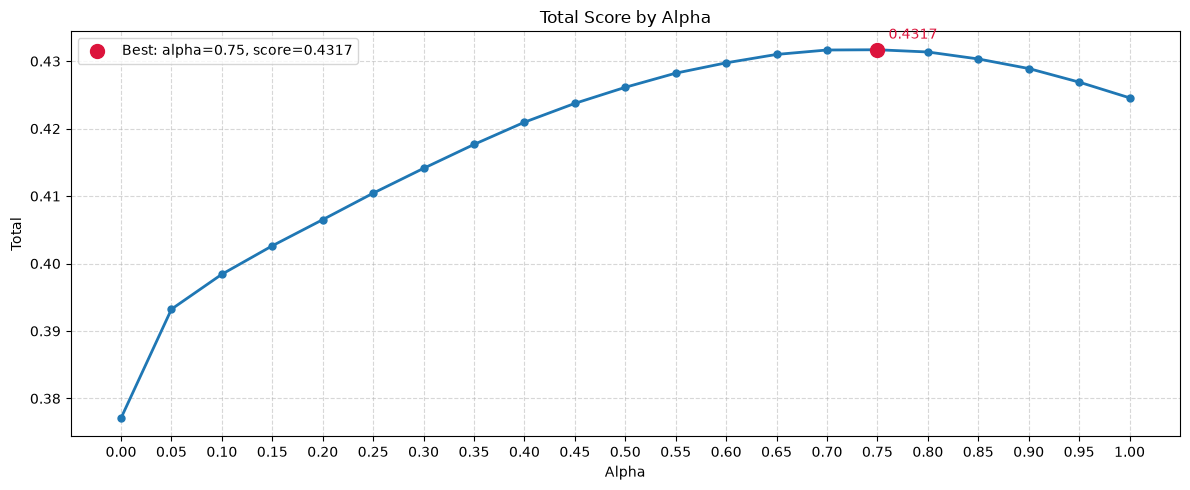

In [18]:
metric_scores = {
    metric: scores[metric]
    for metric in metric_columns
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 5),
    sharex=True,
)
axes = axes.ravel()

for axis, (metric, values) in zip(axes, metric_scores.items()):
    best_index = int(np.argmax(values))
    best_alpha = tuning_df.loc[best_index, "alpha"]
    best_value = values[best_index]

    axis.plot(
        tuning_df["alpha"],
        values,
        marker="o",
        linewidth=2,
        markersize=4,
    )
    axis.scatter(
        best_alpha,
        best_value,
        color="crimson",
        s=80,
        zorder=3,
        label=f"Best: alpha={best_alpha:.2f}, score={best_value:.4f}",
    )
    axis.annotate(
        f"{best_value:.4f}",
        xy=(best_alpha, best_value),
        xytext=(6, 6),
        textcoords="offset points",
        color="crimson",
        fontsize=9,
    )
    axis.set_title(f"{metric} by Alpha")
    axis.set_ylabel(metric)
    axis.grid(True, linestyle="--", alpha=0.5)
    axis.legend(fontsize=8)

for axis in axes[2:]:
    axis.set_xlabel("Alpha")

for axis in axes:
    axis.set_xticks(tuning_df["alpha"])

fig.suptitle("Evaluation Metrics by Alpha", fontsize=14)
fig.tight_layout()
plt.show()

fig_total, axis_total = plt.subplots(figsize=(12, 5))
values = scores["Total"]
best_index = int(np.argmax(values))
best_alpha = tuning_df.loc[best_index, "alpha"]
best_value = values[best_index]

axis_total.plot(
    tuning_df["alpha"],
    values,
    marker="o",
    linewidth=2,
    markersize=5,
)
axis_total.scatter(
    best_alpha,
    best_value,
    color="crimson",
    s=100,
    zorder=3,
    label=f"Best: alpha={best_alpha:.2f}, score={best_value:.4f}",
)
axis_total.annotate(
    f"{best_value:.4f}",
    xy=(best_alpha, best_value),
    xytext=(8, 8),
    textcoords="offset points",
    color="crimson",
    fontsize=10,
)
axis_total.set_title("Total Score by Alpha")
axis_total.set_xlabel("Alpha")
axis_total.set_ylabel("Total")
axis_total.set_xticks(tuning_df["alpha"])
axis_total.grid(True, linestyle="--", alpha=0.5)
axis_total.legend()
fig_total.tight_layout()
plt.show()

In [3]:
# Chọn một user để test hai API bằng danh sách title.
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.core.Context import VectorContext

api_test_context = VectorContext(os.path.join(project_root, "data", "primary", "dev_set"))
news_by_id = {
    item["news_id"]: item["title"]
    for item in api_test_context.createTitleList()
}
behaviors_for_api_test = api_test_context.createImpressed()

selected_api_test_user = None

for behavior_id, behavior in behaviors_for_api_test.items():
    history_ids = behavior["history"].split()
    impression_ids = [item["news_id"] for item in behavior["impressions"]]

    if not (5 <= len(history_ids) <= 6 and 6 <= len(impression_ids) <= 7):
        continue

    if all(news_id in news_by_id for news_id in history_ids + impression_ids):
        selected_api_test_user = {
            "behavior_id": behavior_id,
            "user_id": behavior["user_id"],
            "history_ids": history_ids,
            "impression_ids": impression_ids,
            "history_titles": [news_by_id[news_id] for news_id in history_ids],
            "impression_titles": [news_by_id[news_id] for news_id in impression_ids],
        }
        break

if selected_api_test_user is None:
    raise ValueError(
        "Không tìm thấy user có 5-6 news trong history và 6-7 news trong impression."
    )

history_titles: list[str] = selected_api_test_user["history_titles"]
impression_titles: list[str] = selected_api_test_user["impression_titles"]

print(f"User ID: {selected_api_test_user['user_id']}")
print(f"Behavior ID: {selected_api_test_user['behavior_id']}")
print(f"history_titles ({len(history_titles)}):")
print(history_titles)
print(f"impression_titles ({len(impression_titles)}):")
print(impression_titles)


User ID: U397059
Behavior ID: 91
history_titles (6):
['NFL Week 9 Power Rankings: More ammo for Belichick as greatest coach ever', 'Former NBA first-round pick Jim Farmer arrested in sex sting operation', 'Clippers set bad precedent resting Kawhi Leonard against Bucks', "The Latest: Kansas City to remove King's name from street", '7 biggest takeaways from the opening College Football Playoff rankings', "Pregnant U.S. women's soccer star Alex Morgan still plans to play in 2020 Summer Olympics"]
impression_titles (7):
["Taylor Swift Rep Hits Back at Big Machine, Claims She's Actually Owed $7.9 Million in Unpaid Royalties", "Some believe Mason Rudolph, hit in head with his own helmet, isn't getting enough blame", 'The Hottest Tech Gifts This Holiday Season', 'U.S. Troops Will Die If They Remain in Syria, Bashar Al-Assad Warns', "Report: Police investigating woman's death after Redskins' player Montae Nicholson took her to hospital", "13 Reasons Why's Christian Navarro Slams Disney for Cas